In [13]:
import numpy as np
import matplotlib.pyplot as plt
import re

In [14]:
# --- 1. HÀM ĐỌC DỮ LIỆU CHUẨN ---
def parse_vrp_file(content):
    data = {}
    lines = [l.strip() for l in content.split('\n') if l.strip()]

    # Đọc Optimal value
    data['optimal_value'] = None
    for line in lines:
        if "COMMENT" in line:
            # Tìm kiếm mẫu "Optimal value:" theo sau là các chữ số
            match = re.search(r"Optimal value\s*:\s*(\d+)", line)
            if match:
                data['optimal_value'] = int(match.group(1))
            break
    
    # Đọc Capacity
    for line in lines:
        if "CAPACITY" in line:
            data['capacity'] = int(line.split(':')[-1])
            break
            
    # Đọc Tọa độ
    coord_start = lines.index("NODE_COORD_SECTION") + 1
    demands_start = lines.index("DEMAND_SECTION") + 1
    
    coords = []
    for i in range(coord_start, demands_start - 1):
        parts = lines[i].split()
        coords.append([float(parts[1]), float(parts[2])])
    
    # Đọc Nhu cầu
    demands = []
    for i in range(demands_start, lines.index("DEPOT_SECTION")):
        parts = lines[i].split()
        demands.append(int(parts[1]))
        
    data['coords'] = np.array(coords)
    data['demands'] = np.array(demands)
    return data

## GA

In [15]:
# --- 2. LỚP GIẢI TOÁN GA ---
class VRP_Solver_GA:
    def __init__(self, data, pop_size=100, gens=400):
        self.coords = data['coords']
        self.demands = data['demands']
        self.Q = data['capacity']
        self.pop_size = pop_size
        self.gens = gens
        self.n = len(self.demands)
        self.depot = self.coords[0]

    def fitness(self, tour):
        """Giải mã Giant Tour: Tách lộ trình khi vượt quá tải trọng Q """
        dist = 0
        load = 0
        curr_pos = self.depot
        
        for i in tour:
            d = self.demands[i]
            loc = self.coords[i]
            # Kiểm tra ràng buộc tải trọng 
            if load + d > self.Q:
                dist += np.linalg.norm(curr_pos - self.depot)
                dist += np.linalg.norm(self.depot - loc)
                load = d
            else:
                dist += np.linalg.norm(curr_pos - loc)
                load += d
            curr_pos = loc
            
        dist += np.linalg.norm(curr_pos - self.depot)
        return 1 / dist

    def run(self):
        customers = list(range(1, self.n))
        # Khởi tạo quần thể hoán vị [cite: 177]
        pop = [list(np.random.permutation(customers)) for _ in range(self.pop_size)]  # sinh ngẫu nhiên các cá thể
        history = []

        for g in range(self.gens):
            pop = sorted(pop, key=lambda x: self.fitness(x), reverse=True)
            best_dist = 1 / self.fitness(pop[0])
            history.append(best_dist)

            # Lai ghép OX và Đột biến hoán đổi 
            next_gen = pop[:5] # Giữ lại tinh hoa (Elitism)
            while len(next_gen) < self.pop_size:
                p1, p2 = [pop[i] for i in np.random.choice(len(pop[:20]), 2)]
                # Order Crossover (OX) 
                idx = np.random.randint(1, self.n-2)
                child = p1[:idx] + [x for x in p2 if x not in p1[:idx]]
                # Mutation 
                if np.random.rand() < 0.1:
                    a, b = np.random.choice(range(len(child)), 2)
                    child[a], child[b] = child[b], child[a]
                next_gen.append(child)
            pop = next_gen
            
        return pop[0], history

## DE

In [16]:
class VRP_Solver_DE:
    def __init__(self, data, pop_size=50, f_weight=0.5, cr_prob=0.7, gens=1000):
        self.coords = data['coords']
        self.demands = data['demands']
        self.Q = data['capacity']
        self.n_customers = len(self.demands) - 1
        self.pop_size = pop_size
        self.F = f_weight  # Hệ số đột biến (Mutation scale factor)
        self.CR = cr_prob  # Xác suất lai ghép (Crossover probability)
        self.gens = gens
        self.depot = self.coords[0]

    def fitness(self, random_keys):
        """Giải mã Random Keys thành hoán vị và tính tổng quãng đường"""
        # 1. Giải mã: Sắp xếp chỉ số dựa trên giá trị Random Keys
        tour = np.argsort(random_keys) + 1 # +1 vì bỏ qua Depot ở index 0
        
        dist = 0
        load = 0
        curr_pos = self.depot
        
        for i in tour:
            d = self.demands[i]
            loc = self.coords[i]
            if load + d > self.Q:
                dist += np.linalg.norm(curr_pos - self.depot)
                dist += np.linalg.norm(self.depot - loc)
                load = d
            else:
                dist += np.linalg.norm(curr_pos - loc)
                load += d
            curr_pos = loc
            
        dist += np.linalg.norm(curr_pos - self.depot)
        return dist

    def run(self):
        # Khởi tạo quần thể: Mỗi cá thể là một vector số thực [0, 1]
        pop = np.random.rand(self.pop_size, self.n_customers)
        fitness_values = np.array([self.fitness(ind) for ind in pop])
        
        history = []
        
        for g in range(self.gens):
            for i in range(self.pop_size):
                # 1. Đột biến (Mutation): Chọn 3 cá thể ngẫu nhiên r1, r2, r3 khác i
                idxs = [idx for idx in range(self.pop_size) if idx != i]
                r1, r2, r3 = pop[np.random.choice(idxs, 3, replace=False)]
                
                # Tạo vector đột biến (Donor vector): V = r1 + F * (r2 - r3)
                v_donor = r1 + self.F * (r2 - r3)
                v_donor = np.clip(v_donor, 0, 1) # Giữ giá trị trong [0, 1]
                
                # 2. Lai ghép (Crossover): Kết hợp cá thể hiện tại với vector đột biến
                trial = np.copy(pop[i])
                j_rand = np.random.randint(self.n_customers)
                for j in range(self.n_customers):
                    if np.random.rand() < self.CR or j == j_rand:
                        trial[j] = v_donor[j]
                
                # 3. Chọn lọc (Selection): So sánh trial với cá thể hiện tại
                f_trial = self.fitness(trial)
                if f_trial < fitness_values[i]:
                    pop[i] = trial
                    fitness_values[i] = f_trial
            
            best_idx = np.argmin(fitness_values)
            history.append(fitness_values[best_idx])
            
        return np.argsort(pop[best_idx]) + 1, history

In [17]:
def run_experiment(data, n_runs=30):
    ga_histories = []
    de_histories = []
    
    print(f"Bắt đầu thí nghiệm chạy 30 lần cho mỗi thuật toán...")
    
    for i in range(n_runs):
        # Chạy GA
        ga_solver = VRP_Solver_GA(data, pop_size=100, gens=1000)
        _, ga_hist = ga_solver.run()
        ga_histories.append(ga_hist)
        
        # Chạy DE
        de_solver = VRP_Solver_DE(data, pop_size=50, gens=1000)
        _, de_hist = de_solver.run()
        de_histories.append(de_hist)
        
    # Tính trung bình theo từng thế hệ (axis=0)
    ga_mean = np.mean(ga_histories, axis=0)
    de_mean = np.mean(de_histories, axis=0)
    
    return ga_mean, de_mean


Bắt đầu thí nghiệm chạy 30 lần cho mỗi thuật toán...


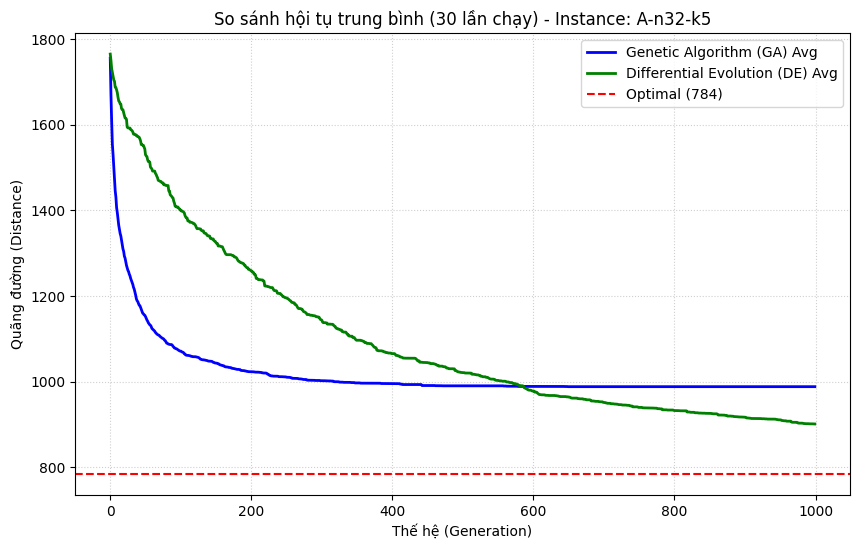


--- KẾT QUẢ TRUNG BÌNH SAU 30 LẦN ---
GA Average: 988.04
DE Average: 900.99
Gap GA: 26.03%
Gap DE: 14.92%


In [18]:
file_path = "./Data/A-n32-k5.vrp"

# Mở và đọc nội dung file
with open(file_path, 'r') as f:
    file_content = f.read()


data = parse_vrp_file(file_content)
opt_val = data['optimal_value']

# Chạy thí nghiệm
ga_avg_history, de_avg_history = run_experiment(data, n_runs=30)

# --- VẼ BIỂU ĐỒ ---
plt.figure(figsize=(10, 6))
plt.plot(ga_avg_history, label='Genetic Algorithm (GA) Avg', color='blue', linewidth=2)
plt.plot(de_avg_history, label='Differential Evolution (DE) Avg', color='green', linewidth=2)

if opt_val:
    plt.axhline(y=opt_val, color='red', linestyle='--', label=f'Optimal ({opt_val})')

plt.title(f"So sánh hội tụ trung bình (30 lần chạy) - Instance: A-n32-k5")
plt.xlabel("Thế hệ (Generation)")
plt.ylabel("Quãng đường (Distance)")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend()
plt.show()

# In kết quả cuối cùng
print(f"\n--- KẾT QUẢ TRUNG BÌNH SAU 30 LẦN ---")
print(f"GA Average: {ga_avg_history[-1]:.2f}")
print(f"DE Average: {de_avg_history[-1]:.2f}")
if opt_val:
    print(f"Gap GA: {((ga_avg_history[-1]-opt_val)/opt_val)*100:.2f}%")
    print(f"Gap DE: {((de_avg_history[-1]-opt_val)/opt_val)*100:.2f}%")